In [33]:
import numpy as np
import matplotlib.pyplot as plt
import copy

In [34]:
launch_angle = 0 #degrees

v0_abs = 20 #m/s

v0x = v0_abs * np.cos(np.radians(launch_angle))
v0y = 0
v0z = v0_abs * np.sin(np.radians(launch_angle))

v0 = np.array([[v0x, v0y, v0z]])

r_body = 0.1 #m
A_body = np.pi * r_body**2 #m^2
l_wing = 0.5 #m
h_wing = 0.05 #m
A_wing = l_wing * h_wing #m^2
m = 1 #kg
g_val = 9.82 #m/s^2

In [35]:
data_open = []
tstep = 0.1 #s
rho_air = 1.225
C_d_body = 0.05
C_d_wing = 0.1
g = np.array([[0, 0, g_val]])

pos = np.array([[0, 0, 5000]])
v = v0
data_open = copy.copy(pos)
i = 0

while  pos[0,2] >= 0:
    pos = pos+v*tstep
    normv = np.sqrt((v**2).sum())
    D_body = 1/2*C_d_body*rho_air*A_body*v*normv/m
    D_wing = 1/2*C_d_wing*rho_air*A_wing*v*normv/m
    #D = 0
    #print('D: '+str(D))
    #print('v: '+str(v))
    v = v-D_body*tstep-D_wing*tstep-g*tstep
    #print('v after: '+str(v))
    data_open = np.concatenate((data_open, pos))

In [36]:
data_closed = []

pos = np.array([[0, 0, 5000]])
v = v0
data_closed = copy.copy(pos)
i = 0

while  pos[0,2] >= 0:
    pos = pos+v*tstep
    normv = np.sqrt((v**2).sum())
    D_body = 1/2*C_d_body*rho_air*A_body*v*normv/m
    #D = 0
    #print('D: '+str(D))
    #print('v: '+str(v))
    v = v-D_body*tstep-g*tstep
    #print('v after: '+str(v))
    data_closed = np.concatenate((data_closed, pos))

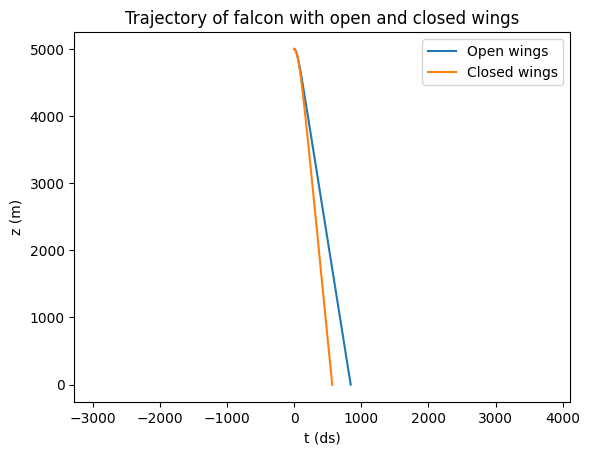

In [37]:
fig, ax = plt.subplots()
ax.plot(data_open[:,2], label='Open wings')
ax.plot(data_closed[:,2], label='Closed wings')
ax.set_xlabel('t (ds)')
ax.set_ylabel('z (m)')
ax.set_title('Trajectory of falcon with open and closed wings')
ax.legend()
ax.set_aspect('equal', adjustable='datalim')
plt.show()

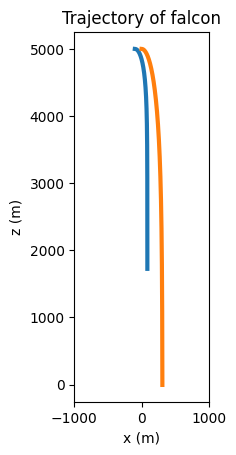

In [38]:
fig, ax = plt.subplots()
ax.plot(data_open[:len(data_closed),0]-100, data_open[:len(data_closed),2], label='Open wings', linewidth=3)
ax.plot(data_closed[:,0], data_closed[:,2], label='Closed wings', linewidth=3)
ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.set_title('Trajectory of falcon')
#ax.legend()
ax.set_xlim(-1000, 1000)
ax.set_aspect('equal', adjustable='box')
plt.savefig("C:\\Users\\emil\\OneDrive\\DTU\\6. semester\\Bio\\falcon_trajectory.png", format='png', dpi=1000)
plt.show()

In [39]:
v_terminal_closed = np.linalg.norm(data_closed[-1] - data_closed[-2]) /tstep
v_closedterminal_open = np.linalg.norm(data_open[len(data_closed)-1] - data_open[len(data_closed)-2]) /tstep
v_terminal_open = np.linalg.norm(data_open[-1] - data_open[-2]) /tstep

print(v_terminal_closed*3.6)
print(v_closedterminal_open*3.6)
print(v_terminal_open*3.6)

363.68904961469366
225.92562297223134
225.92563476358183


In [40]:
print(len(data_closed)*0.1)

56.900000000000006
